# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of this experiment is to determine how different burrito ingredients — protein type, salsa type, and the inclusion of potatoes — affect customer satisfaction ratings, and to identify which ingredient combination produces the highest overall satisfaction.

2. State the outcome variable and how it was measured.

The outcome variable is **customer satisfaction rating**.

It is a **quantitative, approximately continuous variable** measured on a scale from **1 to 10**, where:

- **1 = terrible**

- **10 = amazing**

Each participant rated the burrito they received after tasting it.

3. State the independent variables. What lurking variables may be present?

The independent variables are:

- **Protein** — categorical nominal variable  

  - Bacon

  - Sausage

  - Chorizo

- **Salsa** — categorical nominal variable  

  - Mild

  - Hot

- **Potatoes** — categorical nominal variable  

  - Yes

  - No

Some possible lurking variables include:

- participant spice tolerance  

- individual food preferences  

- hunger level before tasting  

- portion size differences  

- ingredient freshness  

- prior experience with breakfast burritos  

- mood or fatigue during tasting  

- differences in how warm the burritos were served

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

A full factorial design is preferred here because the experiment includes one factor with **3 levels** (Protein), so the design is not naturally suited to a standard $2^k$ fractional factorial structure.

Using the full factorial design allows all possible treatment combinations to be tested, including all interaction effects between protein, salsa, and potatoes. Since food preferences may depend on combinations of ingredients rather than single ingredients alone, observing all treatment combinations is useful.

In this case, the total number of treatment combinations is still manageable:

$$
3 \times 2 \times 2 = 12
$$

so there is less need to reduce the design using a fractional approach.

A fractional factorial design would reduce time and cost, but some effects would become aliased, making interpretation more difficult.

5. State all sets of statistical hypotheses.

Let:

- $\mu_{Bacon}, \mu_{Sausage}, \mu_{Chorizo}$ = mean satisfaction ratings for protein types  
- $\mu_{Hot}, \mu_{Mild}$ = mean satisfaction ratings for salsa types  
- $\mu_{No}, \mu_{Yes}$ = mean satisfaction ratings for potatoes  

We test for main effects and interaction effects.

### Main effect of Protein

$$
H_0: \mu_{Bacon} = \mu_{Sausage} = \mu_{Chorizo}
$$

$$
H_A: \text{At least one protein mean differs}
$$

---

### Main effect of Salsa

$$
H_0: \mu_{Hot} = \mu_{Mild}
$$

$$
H_A: \mu_{Hot} \ne \mu_{Mild}
$$

---

### Main effect of Potatoes

$$
H_0: \mu_{No} = \mu_{Yes}
$$

$$
H_A: \mu_{No} \ne \mu_{Yes}
$$

---

### Protein × Salsa interaction

$$
H_0: PS = 0
$$

$$
H_A: PS \ne 0
$$

---

### Protein × Potatoes interaction

$$
H_0: PPot = 0
$$

$$
H_A: PPot \ne 0
$$

---

### Salsa × Potatoes interaction

$$
H_0: SPot = 0
$$

$$
H_A: SPot \ne 0
$$

---

### Three-way interaction

$$
H_0: PSPot = 0
$$

$$
H_A: PSPot \ne 0
$$

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [1]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("Busters Burritos.xlsx")

# Overall summary
print(df["Satisfaction"].describe())

# Summary by factors
print("\nSummary by Protein")
print(df.groupby("Protein")["Satisfaction"].describe())

print("\nSummary by Salsa")
print(df.groupby("Salsa")["Satisfaction"].describe())

print("\nSummary by Potatoes")
print(df.groupby("Potatoes")["Satisfaction"].describe())

# Mean satisfaction by treatment combination
print("\nMean Satisfaction by Treatment Combination")
print(
    df.groupby(["Protein","Salsa","Potatoes"])["Satisfaction"].mean()
)

count    120.000000
mean       6.543333
std        1.181562
min        3.700000
25%        5.600000
50%        6.700000
75%        7.400000
max        8.900000
Name: Satisfaction, dtype: float64

Summary by Protein
         count    mean       std  min    25%   50%    75%  max
Protein                                                       
Bacon     40.0  6.8500  0.928467  4.9  6.225  6.95  7.500  8.6
Chorizo   40.0  7.0075  1.167374  4.3  6.250  7.05  7.700  8.9
Sausage   40.0  5.7725  1.052710  3.7  5.100  5.60  6.475  8.2

Summary by Salsa
       count      mean       std  min    25%  50%    75%  max
Salsa                                                        
Hot     60.0  6.070000  1.116031  3.7  5.250  6.0  7.025  8.4
Mild    60.0  7.016667  1.055762  5.1  6.275  7.0  7.900  8.9

Summary by Potatoes
          count      mean       std  min    25%   50%    75%  max
Potatoes                                                         
No         60.0  6.335000  1.227071  4.0  5.375  6.

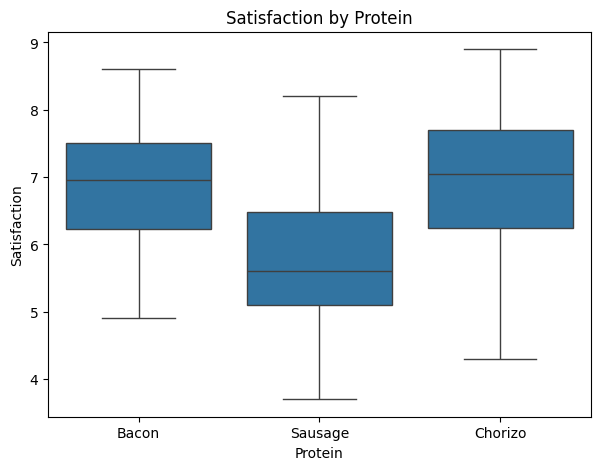

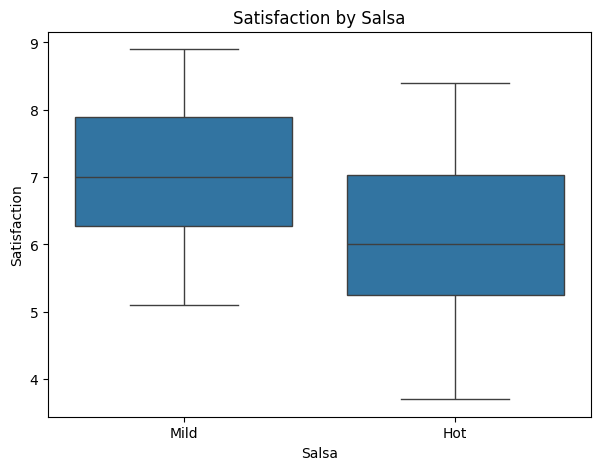

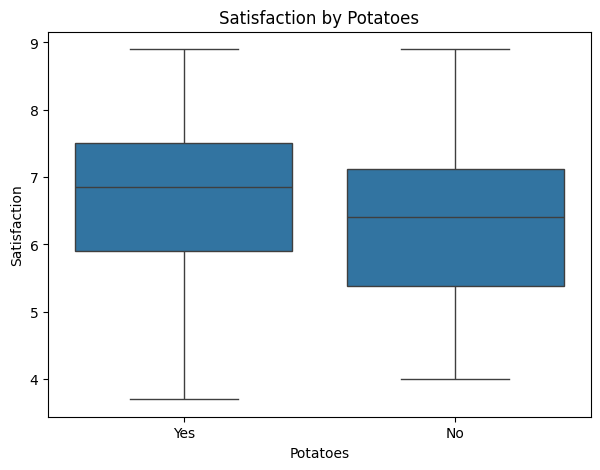

In [2]:
# Boxplots
plt.figure(figsize=(7,5))
sns.boxplot(x="Protein", y="Satisfaction", data=df)
plt.title("Satisfaction by Protein")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Salsa", y="Satisfaction", data=df)
plt.title("Satisfaction by Salsa")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x="Potatoes", y="Satisfaction", data=df)
plt.title("Satisfaction by Potatoes")
plt.show()


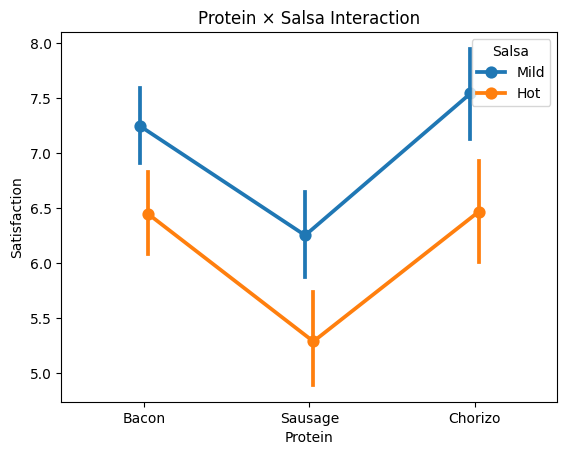

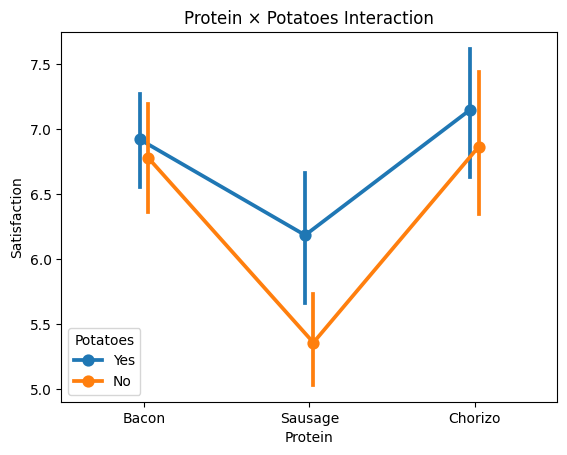

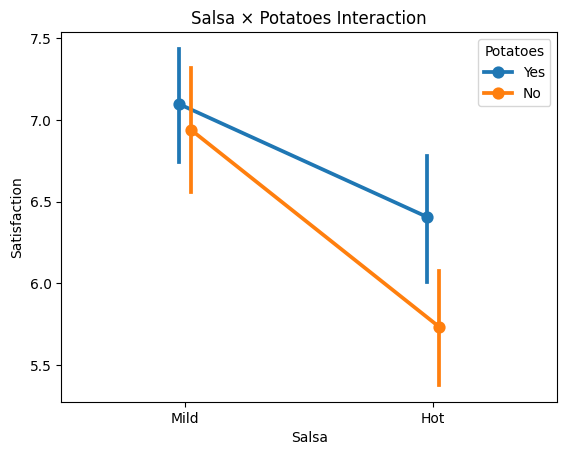

In [3]:
# Interaction plots
sns.pointplot(
    x="Protein",
    y="Satisfaction",
    hue="Salsa",
    data=df,
    dodge=True
)
plt.title("Protein × Salsa Interaction")
plt.show()

sns.pointplot(
    x="Protein",
    y="Satisfaction",
    hue="Potatoes",
    data=df,
    dodge=True
)
plt.title("Protein × Potatoes Interaction")
plt.show()

sns.pointplot(
    x="Salsa",
    y="Satisfaction",
    hue="Potatoes",
    data=df,
    dodge=True
)
plt.title("Salsa × Potatoes Interaction")
plt.show()

Exploratory analysis was performed using summary statistics, boxplots, and interaction plots to examine how satisfaction ratings vary across the ingredient combinations.

The overall mean satisfaction rating was approximately **6.54**, with ratings ranging from **3.7 to 8.9**.

The summary statistics and boxplots show noticeable differences across the protein types. **Chorizo** had the highest average satisfaction rating (mean ≈ **7.01**), followed closely by **Bacon** (mean ≈ **6.85**), while **Sausage** had the lowest average satisfaction rating (mean ≈ **5.77**). The boxplots also show that the distributions for Bacon and Chorizo are generally shifted higher than the distribution for Sausage. This suggests that protein type likely affects customer satisfaction.

For salsa, burritos with **Mild salsa** had noticeably higher satisfaction ratings (mean ≈ **7.02**) compared to **Hot salsa** (mean ≈ **6.07**). The boxplots show that the Mild salsa group is centered at higher satisfaction values overall, suggesting a clear salsa effect.

For potatoes, the difference appears smaller. Burritos with potatoes had a slightly higher average satisfaction rating (mean ≈ **6.75**) than burritos without potatoes (mean ≈ **6.34**), but the boxplots show substantial overlap between the two groups. This suggests that the potatoes effect may be weaker.

The treatment-combination means provide additional support for these patterns. The highest average satisfaction rating was observed for **Chorizo + Mild + No Potatoes** (mean ≈ **7.62**), followed closely by **Chorizo + Mild + Yes Potatoes** (mean ≈ **7.47**). The lowest average satisfaction rating was observed for **Sausage + Hot + No Potatoes** (mean ≈ **4.86**).

The interaction plots were also examined to assess whether the effect of one factor depends on another factor. The **Protein × Salsa** interaction plot shows lines that are mostly parallel, suggesting little evidence of a strong interaction. The **Protein × Potatoes** interaction plot shows slight non-parallel behavior, particularly for Sausage, but the interaction still appears relatively weak overall. The **Salsa × Potatoes** interaction plot shows some non-parallel pattern, suggesting a possible interaction-like effect, although the main salsa effect still appears stronger than the interaction.

Overall, the exploratory analysis provides stronger support for the alternative hypotheses for the main effects of **Protein** and **Salsa**. The evidence for the main effect of **Potatoes** appears weaker, and the interaction effects do not appear especially strong based on the descriptive analysis alone.

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

                            sum_sq     df           F        PR(>F)
Intercept               388.129000    1.0  455.134984  1.589770e-40
Protein                  11.512667    2.0    6.750098  1.728726e-03
Salsa                     6.050000    1.0    7.094463  8.915854e-03
Potatoes                  0.968000    1.0    1.135114  2.890632e-01
Protein:Salsa             0.730333    2.0    0.428208  6.527771e-01
Protein:Potatoes          0.457333    2.0    0.268143  7.653058e-01
Salsa:Potatoes            0.900000    1.0    1.055375  3.065679e-01
Protein:Salsa:Potatoes    0.828167    2.0    0.485570  6.166832e-01
Residual                 92.100000  108.0         NaN           NaN


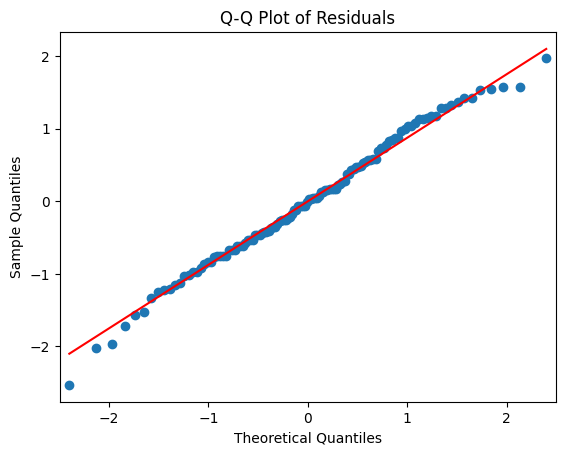

Shapiro-Wilk Statistic: 0.9912132000918904
p-value: 0.6465112757958724


In [4]:
## Question 7 Code ##
import statsmodels.api as sm

from statsmodels.formula.api import ols

import scipy.stats as stats

import matplotlib.pyplot as plt

# Fit full factorial ANOVA model

model = ols(

    'Satisfaction ~ Protein * Salsa * Potatoes',

    data=df

).fit()

# Type III ANOVA table

anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)

# Residuals

residuals = model.resid

# Q-Q Plot

sm.qqplot(residuals, line='s')

plt.title("Q-Q Plot of Residuals")

plt.show()

# Shapiro-Wilk Test

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Statistic:", shapiro_test.statistic)

print("p-value:", shapiro_test.pvalue)

### Interpretation

A full factorial ANOVA model was fit to the data, including all main effects and interaction terms for Protein, Salsa, and Potatoes.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro-Wilk test.

From the Q-Q plot, most of the residuals lie very close to the reference line throughout the center of the distribution. There are a few observations in the upper and lower tails that deviate somewhat from the line, but the deviations are relatively small and there is no strong systematic pattern or curvature. Overall, the plot suggests that the residuals are approximately normally distributed.

The Shapiro-Wilk test provides a formal assessment of normality. The test produced a p-value of approximately **0.647**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

Overall, both the visual method and the formal testing method suggest that the normality assumption is reasonably satisfied for this ANOVA model.

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

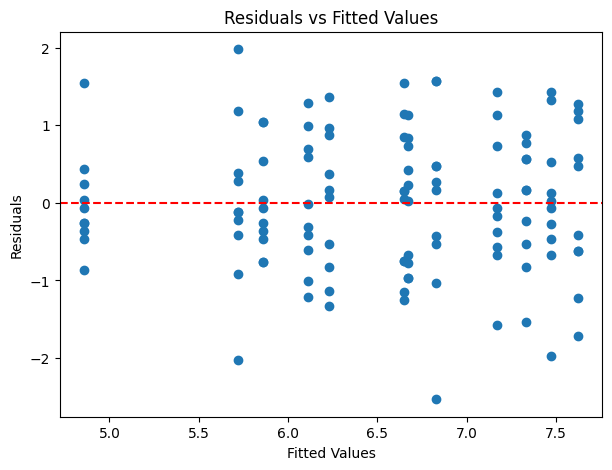

Breusch-Pagan Test Statistic: 8.62394660642261
p-value: 0.656559099121756


In [5]:
## Question 8 Code ##
from statsmodels.stats.diagnostic import het_breuschpagan

# Residuals and fitted values

residuals = model.resid

fitted_values = model.fittedvalues

# Residuals vs Fitted Plot

plt.figure(figsize=(7,5))

plt.scatter(fitted_values, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

# Breusch-Pagan Test

bp_test = het_breuschpagan(residuals, model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])

print("p-value:", bp_test[1])

### Interpretation

The constant variance assumption was assessed using both a residuals versus fitted values plot and the Breusch-Pagan test.

From the residuals versus fitted values plot, the residuals appear to be randomly scattered around zero across the range of fitted values. There is no clear funnel shape, curved pattern, or other systematic structure in the plot. The spread of the residuals appears reasonably similar across the fitted values, although there is some natural variability and a few more extreme residuals.

The Breusch-Pagan test provides a formal assessment of constant variance. The test produced a p-value of approximately **0.657**, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

Overall, both the visual method and the formal testing method suggest that the constant variance assumption is reasonably satisfied for this ANOVA model.

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

## Question 9 Interpretation

The full factorial ANOVA model produced the following results:

- **Protein:** \(F = 6.750,\; p = 0.0017\)
- **Salsa:** \(F = 7.094,\; p = 0.0089\)
- **Potatoes:** \(F = 1.135,\; p = 0.2891\)
- **Protein × Salsa:** \(F = 0.428,\; p = 0.6528\)
- **Protein × Potatoes:** \(F = 0.268,\; p = 0.7653\)
- **Salsa × Potatoes:** \(F = 1.055,\; p = 0.3066\)
- **Protein × Salsa × Potatoes:** \(F = 0.486,\; p = 0.6167\)

Based on these results, the main effects of **Protein** and **Salsa** are statistically significant at the 0.05 level. This suggests that different protein types and salsa types are associated with differences in mean customer satisfaction ratings.

The main effect of **Potatoes** is not statistically significant, indicating that there is not strong evidence that adding potatoes changes satisfaction ratings on average.

For the interaction effects, none of the two-way or three-way interactions are statistically significant. This suggests that the effect of one factor does not appear to depend strongly on the levels of the other factors. In other words, the factors appear to act mostly independently in their effects on satisfaction ratings.

Overall, the results provide stronger support for the alternative hypotheses for the main effects of **Protein** and **Salsa**, while the results support the null hypotheses for **Potatoes** and all interaction effects.

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [7]:
## Question 10 Code ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD for Protein

tukey_protein = pairwise_tukeyhsd(

    endog=df["Satisfaction"],

    groups=df["Protein"],

    alpha=0.05

)

print(tukey_protein)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo   0.1575 0.7824  -0.402   0.717  False
  Bacon Sausage  -1.0775    0.0  -1.637  -0.518   True
Chorizo Sausage   -1.235    0.0 -1.7945 -0.6755   True
------------------------------------------------------


### Interpretation

Since the main effects of **Protein** and **Salsa** were found to be statistically significant, post-hoc analysis was considered for those factors. However, post-hoc testing is mainly needed for factors with more than two levels.

The factor **Protein** has three levels (Bacon, Sausage, and Chorizo), so a Tukey HSD post-hoc test was performed to determine which protein groups differ significantly from one another.

The Tukey HSD results showed that:

- **Bacon** produced significantly higher satisfaction ratings than **Sausage** (\(p < 0.001\)).
- **Chorizo** also produced significantly higher satisfaction ratings than **Sausage** (\(p < 0.001\)).
- The difference between **Bacon** and **Chorizo** was not statistically significant (\(p = 0.782\)).

These results suggest that both Bacon and Chorizo are preferred over Sausage, while Bacon and Chorizo perform similarly overall.

Although **Salsa** was statistically significant, post-hoc testing was not necessary because Salsa only has two levels (Hot and Mild). The ANOVA result itself already fully captures the difference between those two groups. The results showed that Mild salsa produced significantly higher satisfaction ratings than Hot salsa.

Post-hoc testing was not conducted for Potatoes or any interaction effects because those effects were not statistically significant in the ANOVA model. When an overall effect is not statistically significant, additional pairwise comparisons are generally not appropriate.

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [8]:
## Question 11 Code ##
# Partial eta squared for main effects

ss_error = anova_table.loc["Residual", "sum_sq"]

partial_eta_squared = {}

for effect in ["Protein", "Salsa", "Potatoes"]:

    ss_effect = anova_table.loc[effect, "sum_sq"]

    partial_eta_squared[effect] = ss_effect / (ss_effect + ss_error)

print(partial_eta_squared)

{'Protein': np.float64(0.11111254093772366), 'Salsa': np.float64(0.06164034640855815), 'Potatoes': np.float64(0.01040099712038525)}


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

The results of this experiment suggest that both **Protein** and **Salsa** have meaningful effects on customer satisfaction ratings, while the effect of **Potatoes** appears to be much smaller. In particular, burritos made with **Chorizo** or **Bacon** generally received higher ratings than burritos made with **Sausage**, and burritos with **Mild salsa** consistently received higher satisfaction ratings than those with **Hot salsa**.

The ANOVA results showed statistically significant main effects for Protein and Salsa, while none of the interaction effects were statistically significant. This suggests that the factors mostly act independently in their effects on customer satisfaction. The partial $\eta^2$ values also indicated that Protein was the most important factor, followed by Salsa, while Potatoes explained very little variability in ratings.

The treatment-combination means further support these findings. The highest average satisfaction rating was observed for:

- **Chorizo + Mild + No Potatoes** (mean ≈ 7.62)

Other highly rated combinations included:

- **Chorizo + Mild + Yes Potatoes** (mean ≈ 7.47)

- **Bacon + Mild + No Potatoes** (mean ≈ 7.33)

- **Bacon + Mild + Yes Potatoes** (mean ≈ 7.17)

Based on these results, the burrito combinations that should most likely be included regularly on the menu are those using:

- **Chorizo or Bacon**

- **Mild salsa**

- Potatoes may be optional since their effect appears relatively small

There are several limitations to this experiment. The participants may not fully represent the broader customer population, and individual food preferences could influence ratings. The experiment also only considered three ingredients, while other factors such as cheese, tortilla type, portion size, or freshness may also affect satisfaction. In addition, customer ratings are subjective and may vary depending on hunger level, spice tolerance, or prior food experiences.

For future research, a larger and more diverse sample of participants could be used to improve generalizability. Additional ingredient factors could also be studied, and repeated experiments across different locations or times could help determine whether the results remain consistent across customer groups.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [ ]:
## Question 6 Code ##

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3. What is the difference between a fixed effect and a random effect?

4. What is the most important thing you learned in this class?